In [78]:
import os
import opendatasets as od
import pandas as pd
import os
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [9]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Loading Dataset

In [34]:
def load_text_dataset(text_filename, labels_filename):
    text_path = os.path.join("Data", text_filename)
    labels_path = os.path.join("Data", labels_filename)
    
    # 1. Read the text file line by line
    with open(text_path, 'r', encoding='utf-8') as f:
        # .strip() removes the invisible newline characters (\n) at the end of each line
        texts = [line.strip() for line in f.readlines()]
        
    # 2. Read the labels file line by line
    with open(labels_path, 'r', encoding='utf-8') as f:
        # Convert each label directly to an integer
        labels = [int(line.strip()) for line in f.readlines()]
        
    # 3. Combine them into a single, clean DataFrame
    df = pd.DataFrame({
        'tweet': texts,
        'label': labels
    })
    
    return df

In [36]:
train_df = load_text_dataset("train_text.txt", "train_labels.txt")

In [64]:
# --- Phase 2: Category Distribution ---
# Map integers to strings for prettier plotting
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
train_df['label_name'] = train_df['label'].map(label_map)

## Data Profiling

In [44]:
train_df.shape

(45615, 2)

In [48]:
train_df.columns.tolist()


['tweet', 'label']

In [52]:
print("Missing values:\n", train_df.isnull().sum())

Missing values:
 tweet    0
label    0
dtype: int64


In [54]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45615 entries, 0 to 45614
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   45615 non-null  object
 1   label   45615 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 712.9+ KB


In [60]:
# --- Phase 1: Enhanced Duplicate Check ---
# 1. Total duplicates of the tweet text
dup_mask = train_df.duplicated(subset=["tweet"], keep=False)
print(f"Total duplicate text rows: {dup_mask.sum()}")

Total duplicate text rows: 54


In [62]:
# 2. Advanced: Check for label conflicts on identical tweets
conflict_dups = train_df.groupby('tweet')['label'].nunique()
conflicts = conflict_dups[conflict_dups > 1]
print(f"Duplicates with conflicting labels: {len(conflicts)}")

Duplicates with conflicting labels: 3


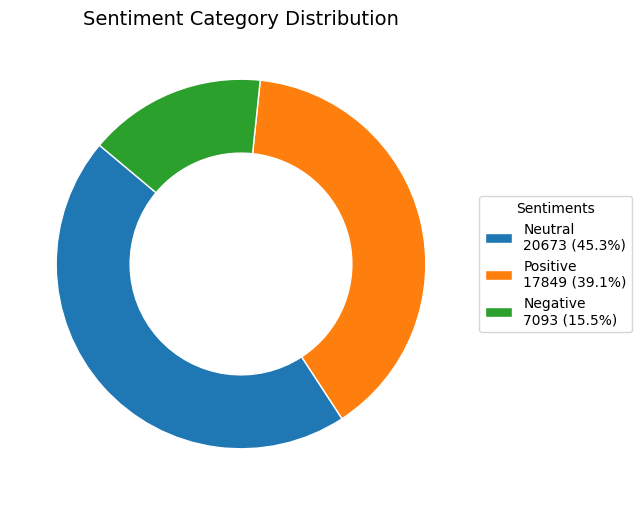

In [66]:
def plot_category_distribution(df, cat_col="label_name"):
    category_counts = df[cat_col].value_counts()
    labels = [f"{cat}\n{count} ({count/len(df)*100:.1f}%)" 
              for cat, count in zip(category_counts.index, category_counts.values)]

    fig, ax = plt.subplots(figsize=(6,6))
    wedges, texts = ax.pie(
        category_counts, startangle=140, wedgeprops=dict(width=0.4, edgecolor="w")
    )
    ax.legend(wedges, labels, title="Sentiments", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    ax.set_title("Sentiment Category Distribution", fontsize=14)
    plt.show()

plot_category_distribution(train_df)

In [68]:
# --- Phase 3: Twitter-Specific Word Frequencies ---
# Enhance standard stopwords with Twitter artifacts
stop_words = set(stopwords.words("english"))
twitter_stops = {"user", "rt", "qt", "amp"}
stop_words.update(twitter_stops)

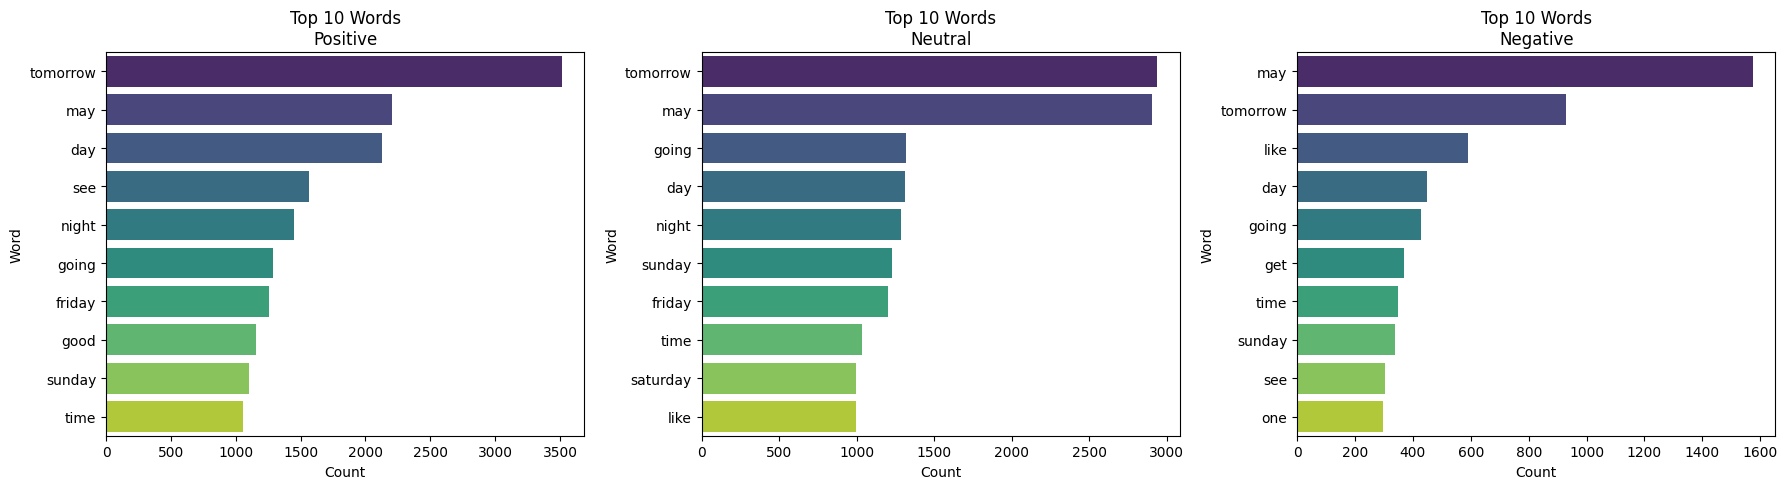

In [76]:
def plot_top_words_per_category(df, text_col="tweet", cat_col="label_name", top_n=10):
    categories = df[cat_col].unique()
    
    fig, axes = plt.subplots(1, len(categories), figsize=(18, 5), sharey=False)
    
    if len(categories) == 1:
        axes = [axes]

    for ax, cat in zip(axes, categories):
        texts = df.loc[df[cat_col] == cat, text_col].astype(str).str.lower().tolist()
        all_text = " ".join(texts)
        
        all_text = re.sub(r"[^a-z\s#]", " ", all_text)        
        tokens = [w for w in all_text.split() if w not in stop_words and len(w) > 2]
        freq = Counter(tokens).most_common(top_n)
        
        if freq:
            words, counts = zip(*freq)
        else:
            words, counts = [], []

        sns.barplot(
            x=list(counts),
            y=list(words),
            hue=list(words),
            ax=ax,
            palette="viridis",
            legend=False
        )

        ax.set_title(f"Top {top_n} Words\n{cat}")
        ax.set_xlabel("Count")
        ax.set_ylabel("Word")

    plt.tight_layout()
    plt.show()

plot_top_words_per_category(train_df)

In [103]:
stop_words_list = list(stopwords.words("english")) + ['user', 'rt', 'qt']

def _simple_clean(s: str) -> str:
    """Enhanced cleaning for Twitter artifacts."""
    s = str(s).lower()
    # Remove mentions (@user) and URLs
    s = re.sub(r"(@[a-z0-9_]+)|(https?://[^\s]+)", " ", s)
    # Keep only letters (standard AFINN words don't have numbers/special chars)
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def plot_length_per_category_row(df, text_col="tweet", cat_col="label", max_words=50):
    """
    Plots word-count histograms for Negative (0), Neutral (1), and Positive (2).
    """
    # Map labels to names for better titles based on image_5d0d3e.png
    label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    cats = sorted(df[cat_col].unique())
    
    fig, axes = plt.subplots(1, len(cats), figsize=(15, 4), sharey=True)

    for ax, c in zip(axes, cats):
        sub = df[df[cat_col] == c][text_col].astype(str).tolist()
        cleaned = [_simple_clean(t) for t in sub]
        # Calculate word counts
        wc = [len(s.split()) for s in cleaned]

        ax.hist(wc, bins=20, color="steelblue", edgecolor="black")
        ax.set_title(f"Label {c}: {label_map.get(c)}\n(Words per Tweet)", fontsize=11)
        ax.set_xlim(0, max_words)
        ax.set_xlabel("Word count")
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

def _top_ngrams(texts, n=2, top_n=10, min_df=2):
    """Returns top n-grams; ignores Twitter noise and common stopwords."""
    if not texts: return [], []
    cleaned = [_simple_clean(t) for t in texts]
    
    # We use our custom stop_words_list to keep the n-grams meaningful
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words_list, min_df=min_df)
    try:
        X = vec.fit_transform(cleaned)
        vocab = np.array(vec.get_feature_names_out())
        freqs = np.asarray(X.sum(axis=0)).ravel()
        order = np.argsort(freqs)[::-1][:top_n]
        return vocab[order].tolist(), freqs[order].tolist()
    except:
        return [], []

def plot_ngrams_per_category_row(df, text_col="tweet", cat_col="label", n=2, top_n=10, min_df=2):
    """Horizontal bar charts for top phrases per sentiment."""
    label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    cats = sorted(df[cat_col].unique())

    fig, axes = plt.subplots(1, len(cats), figsize=(18, 5))

    for ax, c in zip(axes, cats):
        texts = df.loc[df[cat_col] == c, text_col].astype(str).tolist()
        terms, counts = _top_ngrams(texts, n=n, top_n=top_n, min_df=min_df)

        if not terms:
            ax.text(0.5, 0.5, "Insufficient Data", ha="center")
            continue

        ax.barh(np.arange(len(terms))[::-1], counts, color="seagreen")
        ax.set_yticks(np.arange(len(terms))[::-1])
        ax.set_yticklabels(terms)
        ax.set_title(f"{label_map.get(c)} (Label {c})\nTop {n}-grams")

    plt.tight_layout()
    plt.show()

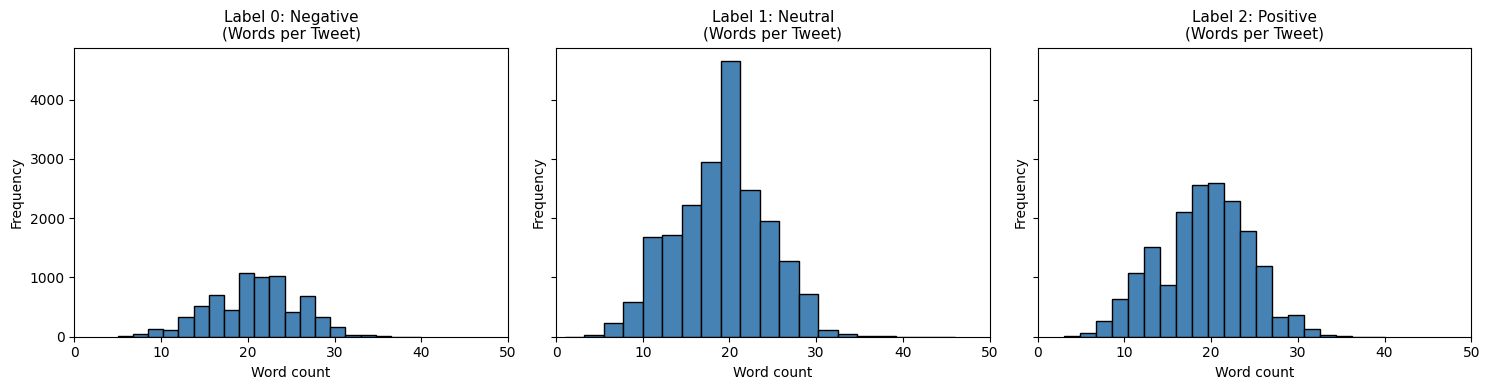

In [100]:
# 1. Visualize the distribution of tweet lengths
# Helps identify if one sentiment category tends to be wordier than others.
plot_length_per_category_row(train_df, text_col="tweet", cat_col="label", max_words=50)

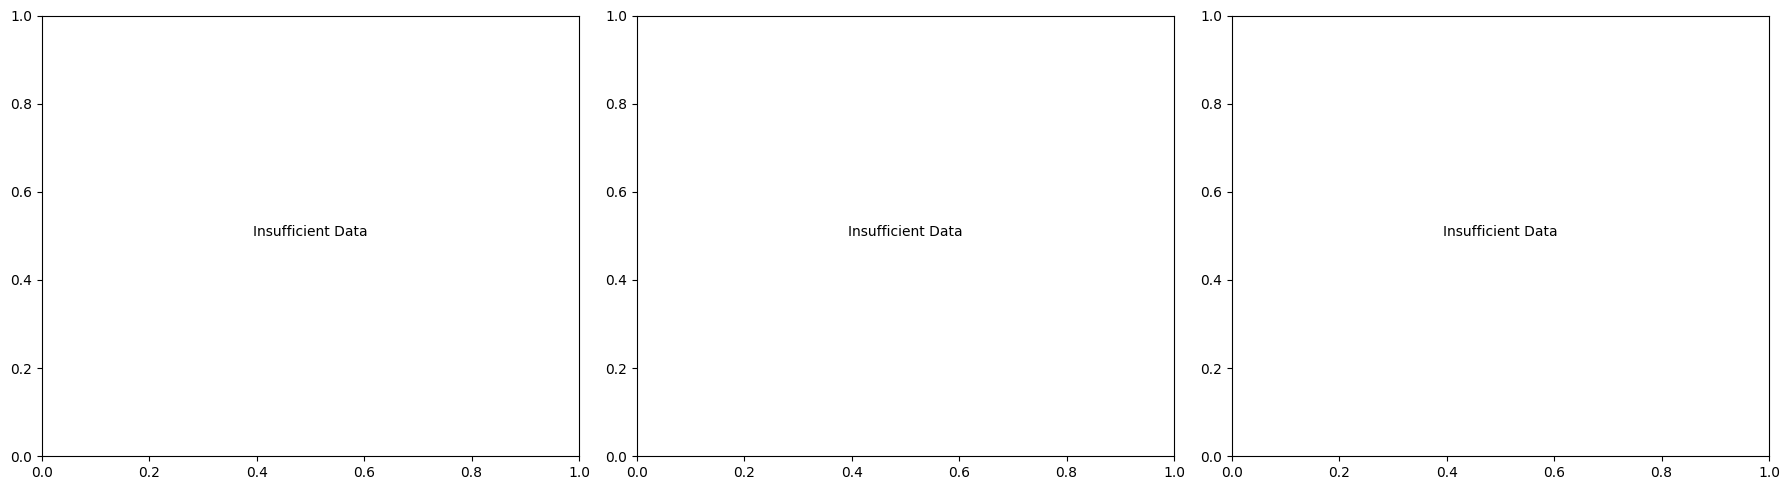

In [105]:
# 2. Visualize the Top 10 Bi-grams (2-word phrases)
# Useful for catching sentiment-carrying phrases like "so happy" or "terrible game".
plot_ngrams_per_category_row(train_df, text_col="tweet", cat_col="label", n=2, top_n=10, min_df=2)

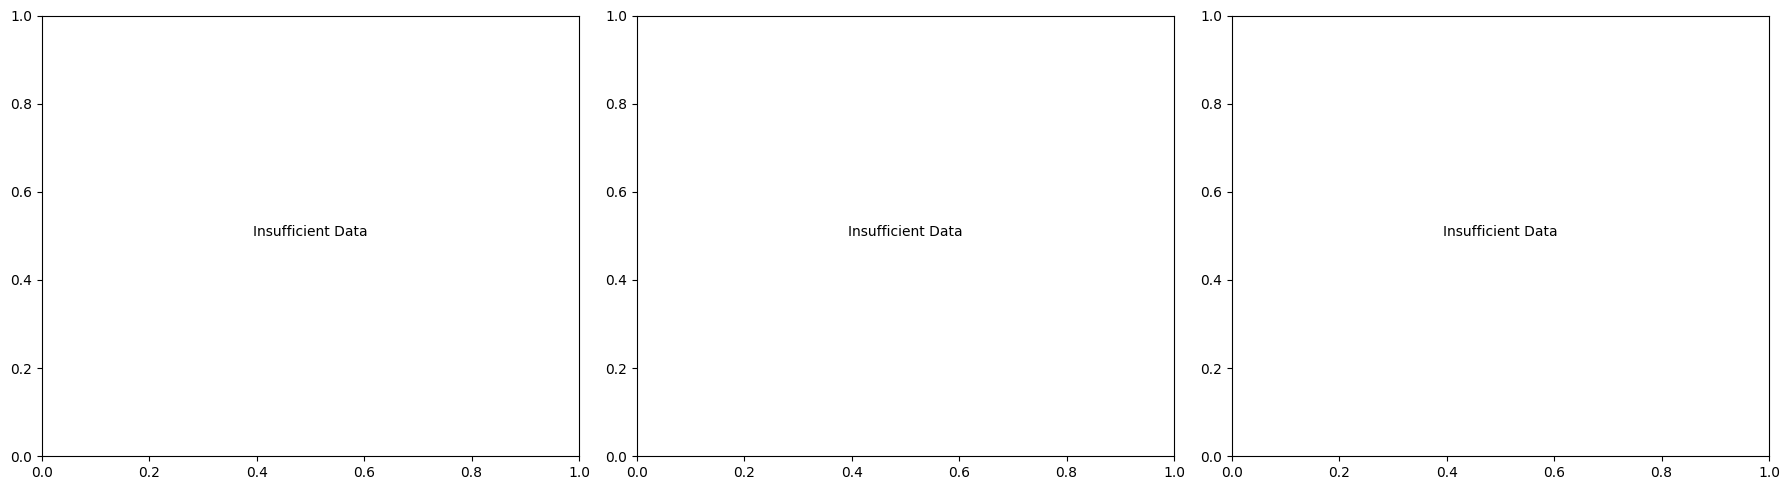

In [107]:
# 2. Visualize the Top 10 Bi-grams (2-word phrases)
# Useful for catching sentiment-carrying phrases like "so happy" or "terrible game".
plot_ngrams_per_category_row(train_df, text_col="tweet", cat_col="label", n=2, top_n=10, min_df=1)

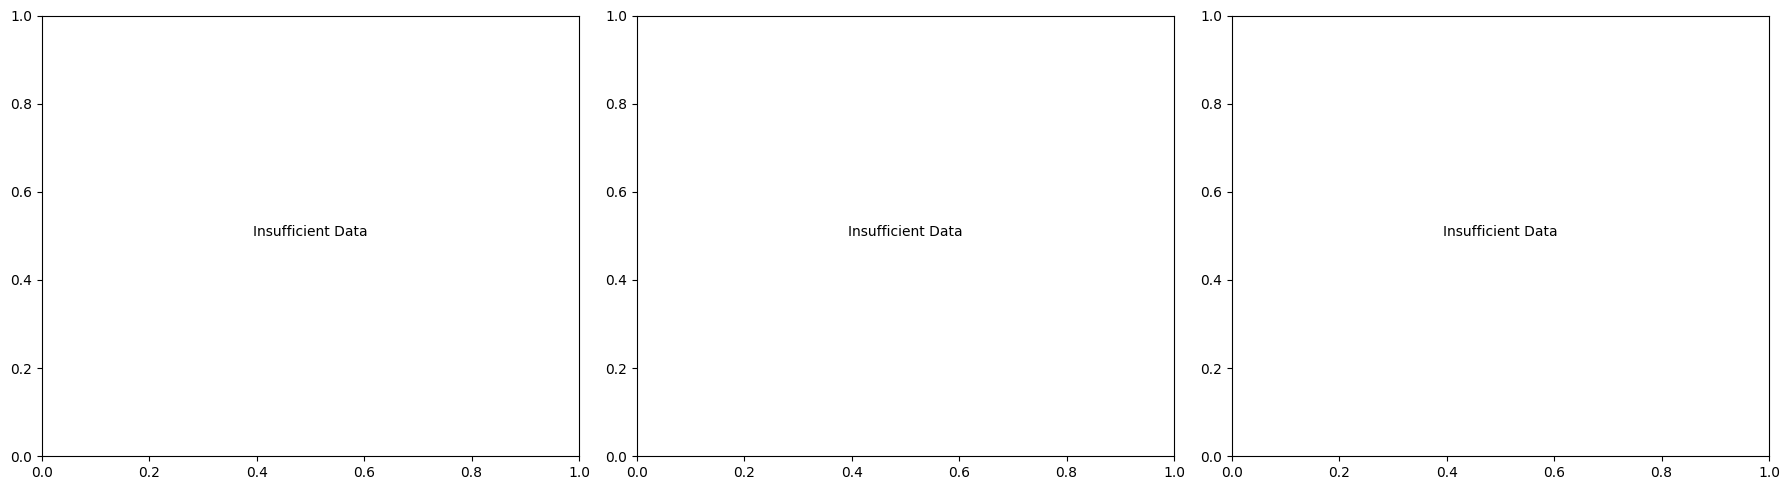

In [109]:
# 3. Visualize the Top 10 Tri-grams (3-word phrases)
# Gives deeper context into specific recurring themes or topics in your data.
plot_ngrams_per_category_row(train_df, text_col="tweet", cat_col="label", n=3, top_n=10, min_df = 1)

---

## Data Preprocessing